# Flight Delay Prediction Model
**Course:** Machine Learning  (**UTA CSE 6363**)     
**Team Members:** Kimberlee Ashmore and Yassien Fadul 

## Dataset

We will use the **The U.S. Bureau of Transportation Statistics**, publicly accessible from the BTS website. BTS currently has data available through June/July 2026, so we will be utilizing the data from Jan 2025 to June 2026. Importantly, BTS defines an arrival as on time when it arrives less than 15 minutes after the scheduled arrival time which we will utilize to determine flight delays and other relavent data.

**1. Setup and extract dataset**
Import necessary libraries and data files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve)

KEEP = ["Year","Month","DayofMonth","DayOfWeek","FlightDate","Reporting_Airline","Origin","Dest",
        "CRSDepTime","CRSElapsedTime","Distance","DepDelay","DepDel15","Cancelled","Diverted", "ArrDelay"]

raw = pd.read_csv("data/dfw_departures.csv", parse_dates=["FlightDate"])
# df = pd.read_csv("data/flights.csv", usecols=lambda c: c in KEEP, low_memory=False)

**2. Clean Data**
clean up data only filtering on columns necessary to compare for flight delay analysis. Because this dataset was so large, we already downloaded and filtered the dataset to focus on flights departing from DFW airport. We have also already filtered the columns by the "KEEP" python list so that we can begin analyzing data.

In [18]:
print(raw.dtypes); print("\nMissing values:\n", raw.isna().sum())
print("\nDate range:", raw.FlightDate.min().date(), "to", raw.FlightDate.max().date())
print("Airlines:", raw.Reporting_Airline.nunique(), "| Destinations:", raw.Dest.nunique())

#Cleaning data - remoce DepDel15 rows that are empty
n0=len(raw)
df = raw[(raw.Cancelled!=1)&(raw.Diverted!=1)].dropna(subset=["DepDel15","CRSDepTime","Distance","CRSElapsedTime"]).copy()
print(f"Removed {(1-len(df)/n0):.2%} of flights (cancelled/diverted/missing). Remaining: {len(df):,}")
df["DepDel15"]=df.DepDel15.astype(int)
print(f"Delay rate (>=15 min): {df.DepDel15.mean():.1%}")
print(f"DepDelay max: {df.DepDelay.max():.0f} min | 99th percentile: {df.DepDelay.quantile(.99):.0f} min")


Year                          int64
Month                         int64
DayofMonth                    int64
DayOfWeek                     int64
FlightDate           datetime64[us]
Reporting_Airline               str
Origin                          str
Dest                            str
CRSDepTime                    int64
DepDelay                    float64
DepDel15                    float64
Cancelled                   float64
Diverted                    float64
CRSElapsedTime              float64
Distance                    float64
dtype: object

Missing values:
 Year                     0
Month                    0
DayofMonth               0
DayOfWeek                0
FlightDate               0
Reporting_Airline        0
Origin                   0
Dest                     0
CRSDepTime               0
DepDelay             14434
DepDel15             14434
Cancelled                0
Diverted                 0
CRSElapsedTime           0
Distance                 0
dtype: int64

Date rang

**3. Analyze Data**


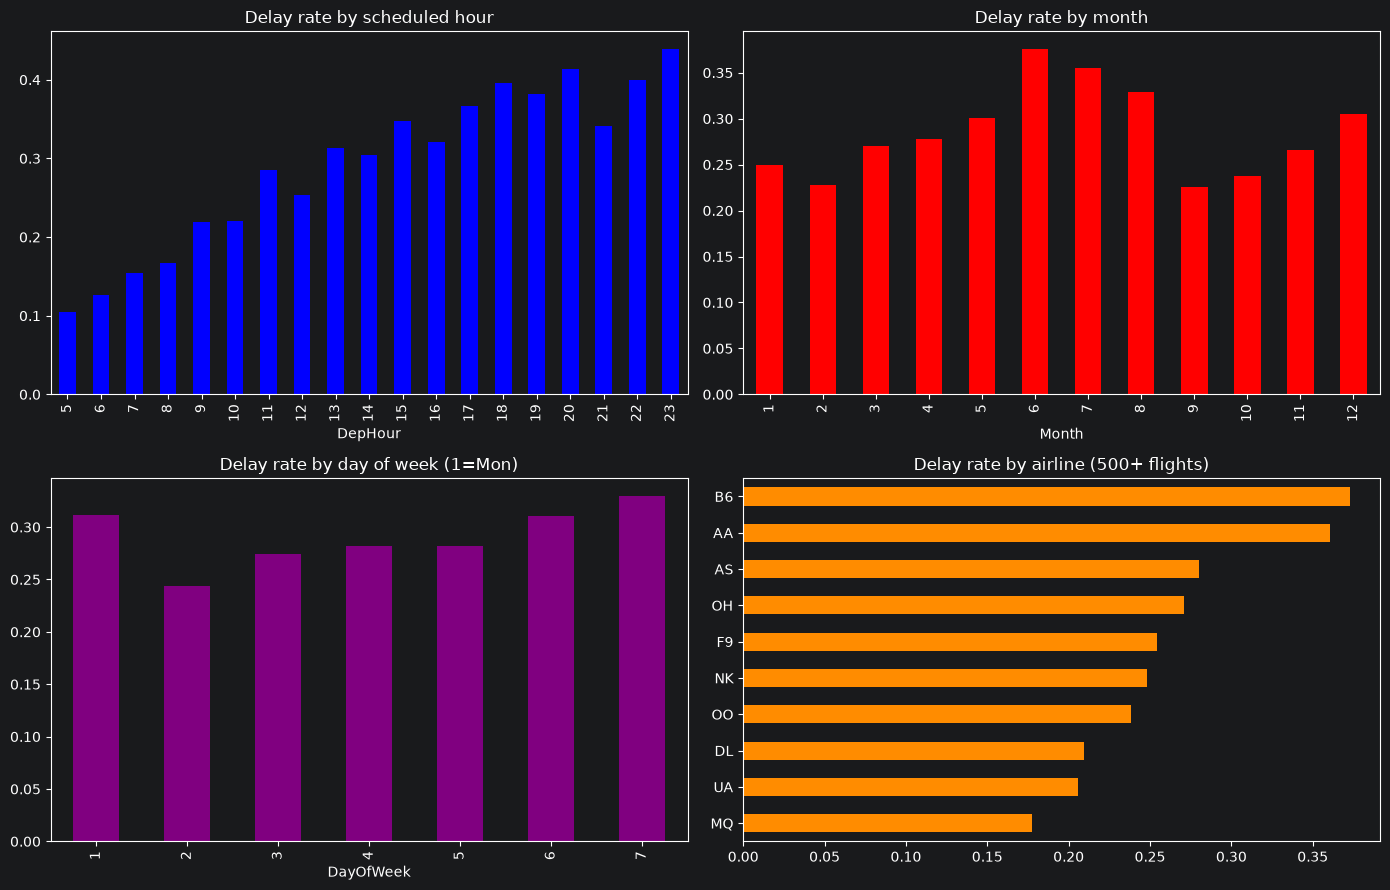

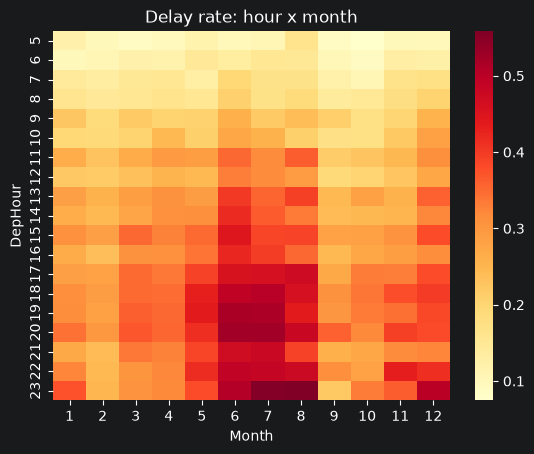

In [22]:
df["DepHour"]=(df.CRSDepTime//100).clip(0,23)
fig,ax=plt.subplots(2,2,figsize=(14,9))
df.groupby("DepHour").DepDel15.mean().plot(kind="bar",ax=ax[0,0],color="blue"); ax[0,0].set_title("Delay rate by scheduled hour")
df.groupby("Month").DepDel15.mean().plot(kind="bar",ax=ax[0,1],color="red"); ax[0,1].set_title("Delay rate by month")
df.groupby("DayOfWeek").DepDel15.mean().plot(kind="bar",ax=ax[1,0],color="purple"); ax[1,0].set_title("Delay rate by day of week (1=Mon)")
a=df.groupby("Reporting_Airline").DepDel15.agg(["mean","size"]); a=a[a["size"]>=500]["mean"].sort_values()
a.plot(kind="barh",ax=ax[1,1],color="darkorange"); ax[1,1].set_title("Delay rate by airline (500+ flights)")
for x in ax.flat: x.set_ylabel("")
plt.tight_layout(); plt.show()


sns.heatmap(df.pivot_table(index="DepHour",columns="Month",values="DepDel15",aggfunc="mean"),cmap="YlOrRd",annot=False)
plt.title("Delay rate: hour x month"); plt.show()

**4. Enacting data analysis**
we are all runnning when there is a struggling team :/


In [4]:
df = df.sort_values(["FlightDate","CRSDepTime"]).reset_index(drop=True)
df["hour_sin"]=np.sin(2*np.pi*df.DepHour/24); df["hour_cos"]=np.cos(2*np.pi*df.DepHour/24)
hol=USFederalHolidayCalendar().holidays(df.FlightDate.min()-pd.Timedelta(days=5), df.FlightDate.max()+pd.Timedelta(days=5))
df["near_holiday"]=df.FlightDate.apply(lambda d: int(any(abs((d-h).days)<=2 for h in hol)))
df["dep_in_hour"]=df.groupby(["FlightDate","DepHour"]).DepHour.transform("size")   # scheduled load
df["is_weekend"]=df.DayOfWeek.isin([6,7]).astype(int)
df.rename(columns={"Reporting_Airline":"Airline"},inplace=True)
df[["Airline","Dest","hour_sin","near_holiday","dep_in_hour"]].head()

,Airline,Dest,hour_sin,near_holiday,dep_in_hour
0,AA,CLT,0.965926,1,11
1,AA,MIA,0.965926,1,11
2,AA,ORD,0.965926,1,11
3,NK,ATL,0.965926,1,11
4,NK,MIA,0.965926,1,11


**5. Linear Regression model (added)**

Your notebook so far loads, cleans, explores and engineers features, but it does not train a model yet (the tree/forest classes are imported but never fitted). Here we add **Linear Regression** to predict *how many minutes late* a flight departs (`DepDelay`), using only schedule-time information.

- **Time-based split:** train on the earliest 75% of dates, test on the most recent 25%.
- **Outliers:** delays can reach 1,000+ minutes and would dominate a least-squares fit. We cap the target at the training 1st and 99th percentiles (winsorizing) for both fitting and scoring.
- **Encoding and scaling:** one-hot for categorical variables (month, day of week, hour, airline, destination) and standardization for numeric ones.
- **Baseline:** always predict the training mean, to show what the model adds.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
SEED = 42

# Time-based split (df is already sorted by date)
cutoff = df.FlightDate.quantile(0.75)
train = df[df.FlightDate <= cutoff].copy()
test  = df[df.FlightDate >  cutoff].copy()
print(f"Train: {len(train):,} rows ({train.FlightDate.min().date()} to {train.FlightDate.max().date()})")
print(f"Test : {len(test):,} rows ({test.FlightDate.min().date()} to {test.FlightDate.max().date()})")

# Cap the target using TRAIN percentiles only
lo, hi = train.DepDelay.quantile([0.01, 0.99])
print(f"Target capped to [{lo:.0f}, {hi:.0f}] minutes")
y_train = train.DepDelay.clip(lo, hi)
y_test  = test.DepDelay.clip(lo, hi)

NUM = ["Distance", "CRSElapsedTime", "dep_in_hour", "near_holiday", "is_weekend", "hour_sin", "hour_cos"]
CAT = ["Month", "DayOfWeek", "DepHour", "Airline", "Dest"]
# X_train, X_test = train[NUM + CAT], test[NUM + CAT]

prep = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=100, sparse_output=False), CAT)])

Train: 361,579 rows (2025-01-01 to 2026-03-15)
Test : 119,625 rows (2026-03-16 to 2026-07-31)
Target capped to [-11, 243] minutes


In [6]:
base = Pipeline([("prep", prep), ("model", DummyRegressor(strategy="mean"))]).fit(X_train, y_train)
lin  = Pipeline([("prep", prep), ("model", LinearRegression())]).fit(X_train, y_train)

def scores(name, m):
    p = m.predict(X_test)
    return {"Model": name, "MAE (min)": mean_absolute_error(y_test, p),
            "RMSE (min)": np.sqrt(mean_squared_error(y_test, p)), "R2": r2_score(y_test, p)}
results = pd.DataFrame([scores("Baseline (train mean)", base), scores("Linear Regression", lin)]).set_index("Model").round(3)
results

,MAE (min),RMSE (min),R2
Model,,,
Baseline (train mean),29.308,46.617,-0.004
Linear Regression,29.123,44.646,0.079


**Reading the regression metrics**
- **MAE** is the average miss in minutes; **RMSE** punishes large misses more.
- **R²** is the share of variation in delay minutes explained. With schedule-only features, a small positive R² (often well under 0.2) is normal, because weather and late inbound aircraft are not in the data. The baseline R² should be near 0 (slightly negative is possible on a shifted test period).

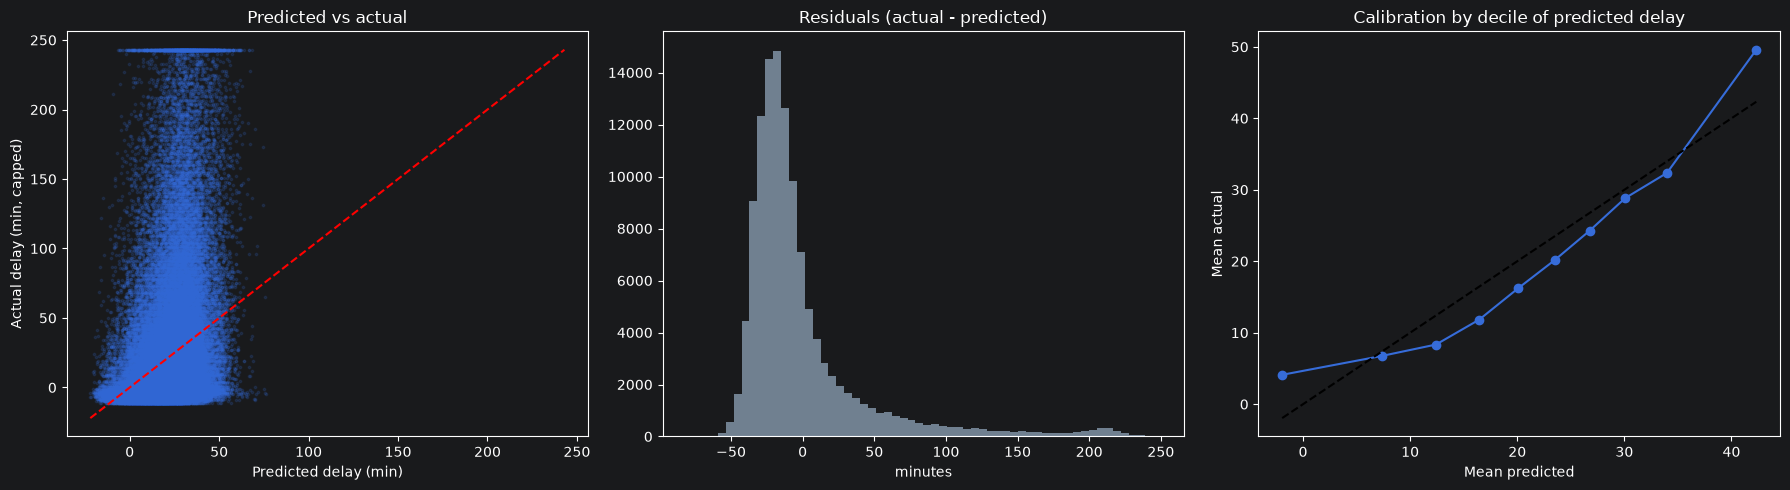

In [7]:
pred = lin.predict(X_test)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(pred, y_test, s=3, alpha=.15); lim=[min(pred.min(),y_test.min()), max(pred.max(),y_test.max())]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("Predicted delay (min)"); ax[0].set_ylabel("Actual delay (min, capped)"); ax[0].set_title("Predicted vs actual")
ax[1].hist(y_test - pred, bins=60, color="slategray"); ax[1].set_title("Residuals (actual - predicted)"); ax[1].set_xlabel("minutes")
tmp = pd.DataFrame({"pred": pred, "actual": y_test.values}); tmp["bin"] = pd.qcut(tmp.pred, 10, duplicates="drop")
g = tmp.groupby("bin", observed=True).mean(); ax[2].plot(g.pred, g.actual, "o-"); ax[2].plot(g.pred, g.pred, "k--")
ax[2].set_title("Calibration by decile of predicted delay"); ax[2].set_xlabel("Mean predicted"); ax[2].set_ylabel("Mean actual")
plt.tight_layout(); plt.show()

**Using the regression as a delay detector.** The predicted minutes can be used as a risk *score*: flights with a higher predicted delay are riskier. Below we measure how well that score separates flights that were actually 15+ minutes late (ROC-AUC) and pick a cutoff in minutes. A cutoff of 15 predicted minutes would flag almost nothing, because averages sit well below individual delays, so we choose the cutoff on a validation slice from the end of the training period.

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.base import clone
actual15 = test.DepDel15.values
print(f"ROC-AUC of predicted minutes vs actual 15+ min delay: {roc_auc_score(actual15, pred):.3f}  (0.5 = no skill)")

# Choose the cutoff on a validation slice (last 20% of train), F1-optimal
k = int(len(train) * 0.8); fit_p, val_p = train.iloc[:k], train.iloc[k:]
m = clone(lin).fit(fit_p[NUM+CAT], fit_p.DepDelay.clip(lo, hi)); pv = m.predict(val_p[NUM+CAT])
cuts = np.quantile(pv, np.linspace(.3, .98, 70))
f1s = [f1_score(val_p.DepDel15, pv >= c) for c in cuts]; CUT = cuts[int(np.argmax(f1s))]
yh = (pred >= CUT).astype(int)
print(f"Cutoff chosen on validation: {CUT:.1f} predicted minutes")
print(f"TEST -> precision {precision_score(actual15, yh):.3f} | recall {recall_score(actual15, yh):.3f} | F1 {f1_score(actual15, yh):.3f}")
print(f"Share of test flights actually delayed 15+: {actual15.mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(actual15, pred, name="Linear Regression score", ax=ax[0]); ax[0].plot([0,1],[0,1],"k--")
ConfusionMatrixDisplay.from_predictions(actual15, yh, ax=ax[1], cmap="Blues"); ax[1].set_title(f"Confusion matrix @ {CUT:.1f} min")
plt.tight_layout(); plt.show()

## 6. What did the model learn? (coefficients)
Each coefficient is the change in predicted delay minutes for that feature, holding the others fixed. Numeric features are standardized, so their coefficients are per 1 standard deviation. Category coefficients are relative to the average of the other categories in the model.

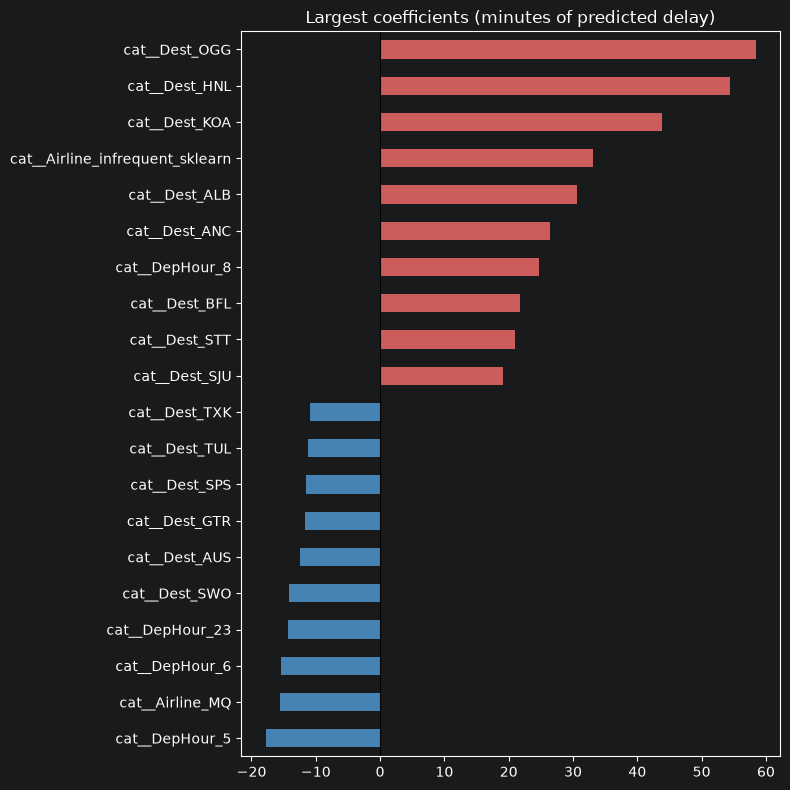

Hour-of-day effects (min, relative):
cat__DepHour_5    -17.80
cat__DepHour_6    -15.42
cat__DepHour_7     10.16
cat__DepHour_8     24.64
cat__DepHour_9     -7.24
cat__DepHour_10    13.12
cat__DepHour_11    -6.70
cat__DepHour_12     7.80
cat__DepHour_13    -9.89
cat__DepHour_14    -1.09
cat__DepHour_15    -9.72
cat__DepHour_16    -2.13
cat__DepHour_17    -5.84
cat__DepHour_18     1.58
cat__DepHour_19    10.96
cat__DepHour_20     2.31
cat__DepHour_21    12.97
cat__DepHour_22     6.59
cat__DepHour_23   -14.30


In [14]:
names = lin.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lin.named_steps["model"].coef_, index=names).sort_values()
top = pd.concat([coef.head(10), coef.tail(10)])
top.plot(kind="barh", figsize=(8, 8), color=np.where(top > 0, "indianred", "steelblue"))
plt.title("Largest coefficients (minutes of predicted delay)"); plt.axvline(0, color="k", lw=.8); plt.tight_layout(); plt.show()

hour = coef[[n for n in names if n.startswith("cat__DepHour_")]]
print("Hour-of-day effects (min, relative):"); print(hour.round(2).to_string())

## 7. Limitations and conclusions (fill in from your results)
- **Why linear regression is limited here:** it assumes each feature adds a fixed number of minutes. Real delays depend on *interactions* (e.g., evening departures in summer storm season at a busy hub) and are heavily skewed, so a linear model underfits. This makes it a useful, interpretable benchmark rather than the final model.
- **Missing information:** weather, late inbound aircraft and air traffic control are not in the data, which caps R² and ROC-AUC.
- **Next step:** compare against the tree-based models you already imported (Decision Tree, Random Forest, HistGradientBoosting) on the same split and report ROC-AUC, precision, recall and F1.

**Conclusions:** Linear Regression reached MAE ___ min and R² ___ (baseline MAE ___), and its predicted minutes separated delayed flights with ROC-AUC ___. The largest drivers were ___.

## 8. k-Nearest Neighbors (added)

k-NN predicts a flight's outcome from the **k most similar historical flights** (similar time of day, season, airline, destination, distance, congestion). It makes no linear assumption, so it can capture interactions that linear regression cannot. We use it two ways on the same time-based split:
- **k-NN Regressor:** predicts delay minutes (directly comparable with Linear Regression).
- **k-NN Classifier:** predicts the probability a flight is delayed 15+ minutes.

**Design notes**
- k-NN is distance-based, so **scaling is essential**; numeric features are standardized and categories one-hot encoded.
- Distance gets noisy with many dimensions, so we use a **compact feature set** (cyclical encodings of hour/month, airline, destination) instead of the full one-hot set used for linear regression.
- k-NN is slow on large data, so **k is tuned on a time-ordered subsample** (`TUNE_STRIDE`), then the final model is fitted on all training data.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import average_precision_score

for d_ in (train, test):
    d_["month_sin"] = np.sin(2*np.pi*d_.Month/12); d_["month_cos"] = np.cos(2*np.pi*d_.Month/12)
    d_["dow_sin"]   = np.sin(2*np.pi*d_.DayOfWeek/7); d_["dow_cos"] = np.cos(2*np.pi*d_.DayOfWeek/7)

KNN_NUM = ["hour_sin","hour_cos","month_sin","month_cos","dow_sin","dow_cos",
           "Distance","CRSElapsedTime","dep_in_hour","near_holiday"]
KNN_CAT = ["Airline","Dest"]
knn_prep = ColumnTransformer([
    ("num", StandardScaler(), KNN_NUM),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=500, sparse_output=False), KNN_CAT)])
Xk_train, Xk_test = train[KNN_NUM+KNN_CAT], test[KNN_NUM+KNN_CAT]

TUNE_STRIDE = 5                       # use every 5th training row (keeps time order) for tuning; set to 1 for all rows
idx = np.arange(0, len(train), TUNE_STRIDE)
grid = {"model__n_neighbors": [15, 31, 61, 101, 201], "model__weights": ["uniform", "distance"]}

In [29]:
# --- k-NN Regressor: tune k with time-series CV, then fit on all training data ---
rs = GridSearchCV(Pipeline([("prep", knn_prep), ("model", KNeighborsRegressor(n_jobs=-1))]), grid,
                  cv=TimeSeriesSplit(3), scoring="neg_mean_absolute_error", n_jobs=1)
rs.fit(Xk_train.iloc[idx], y_train.iloc[idx])
print("Best regressor params:", rs.best_params_, "| CV MAE:", round(-rs.best_score_, 2))
knn_reg = clone(rs.best_estimator_).fit(Xk_train, y_train)
pred_knn = knn_reg.predict(Xk_test)

# --- k-NN Classifier: tune on ROC-AUC ---
cs = GridSearchCV(Pipeline([("prep", knn_prep), ("model", KNeighborsClassifier(n_jobs=-1))]), grid,
                  cv=TimeSeriesSplit(3), scoring="roc_auc", n_jobs=1)
cs.fit(Xk_train.iloc[idx], train.DepDel15.iloc[idx])
print("Best classifier params:", cs.best_params_, "| CV ROC-AUC:", round(cs.best_score_, 3))
knn_clf = clone(cs.best_estimator_).fit(Xk_train, train.DepDel15)
proba_knn = knn_clf.predict_proba(Xk_test)[:, 1]

Best regressor params: {'model__n_neighbors': 201, 'model__weights': 'uniform'} | CV MAE: 28.41


NameError: name 'clone' is not defined

In [ ]:
# Choose the classification threshold on a validation slice (last 20% of train), never on test
k_ = int(len(train)*0.8); fp_, vp_ = train.iloc[:k_], train.iloc[k_:]
mv = clone(knn_clf).fit(fp_[KNN_NUM+KNN_CAT], fp_.DepDel15); pv_ = mv.predict_proba(vp_[KNN_NUM+KNN_CAT])[:,1]
ths = np.linspace(.05, .8, 76); T_KNN = ths[int(np.argmax([f1_score(vp_.DepDel15, pv_>=t) for t in ths]))]
yh_knn = (proba_knn >= T_KNN).astype(int)

rows = [
 {"Model":"Baseline (train mean)", **{k: results.loc["Baseline (train mean)", k] for k in ["MAE (min)","RMSE (min)","R2"]}, "ROC-AUC":0.5},
 {"Model":"Linear Regression", **{k: results.loc["Linear Regression", k] for k in ["MAE (min)","RMSE (min)","R2"]},
  "ROC-AUC":roc_auc_score(actual15, pred), "Precision":precision_score(actual15, yh), "Recall":recall_score(actual15, yh), "F1":f1_score(actual15, yh)},
 {"Model":"k-NN Regressor", "MAE (min)":mean_absolute_error(y_test, pred_knn), "RMSE (min)":np.sqrt(mean_squared_error(y_test, pred_knn)),
  "R2":r2_score(y_test, pred_knn), "ROC-AUC":roc_auc_score(actual15, pred_knn)},
 {"Model":"k-NN Classifier", "ROC-AUC":roc_auc_score(actual15, proba_knn), "PR-AUC":average_precision_score(actual15, proba_knn),
  "Precision":precision_score(actual15, yh_knn), "Recall":recall_score(actual15, yh_knn), "F1":f1_score(actual15, yh_knn)},
]
comparison = pd.DataFrame(rows).set_index("Model").round(3)
print(f"k-NN classifier threshold (validation): {T_KNN:.2f}")
comparison

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
RocCurveDisplay.from_predictions(actual15, pred, name="Linear Regression", ax=ax[0])
RocCurveDisplay.from_predictions(actual15, pred_knn, name="k-NN Regressor", ax=ax[0])
RocCurveDisplay.from_predictions(actual15, proba_knn, name="k-NN Classifier", ax=ax[0]); ax[0].plot([0,1],[0,1],"k--"); ax[0].set_title("ROC curves (test)")
ConfusionMatrixDisplay.from_predictions(actual15, yh_knn, ax=ax[1], cmap="Blues"); ax[1].set_title(f"k-NN classifier @ {T_KNN:.2f}")
# Effect of k on validation performance
ks = [5, 15, 31, 61, 101, 201, 401]; aucs = []
for kk in ks:
    mm = Pipeline([("prep", knn_prep), ("model", KNeighborsClassifier(n_neighbors=kk, n_jobs=-1))]).fit(fp_[KNN_NUM+KNN_CAT].iloc[::TUNE_STRIDE], fp_.DepDel15.iloc[::TUNE_STRIDE])
    aucs.append(roc_auc_score(vp_.DepDel15, mm.predict_proba(vp_[KNN_NUM+KNN_CAT])[:,1]))
ax[2].plot(ks, aucs, "o-"); ax[2].set_xscale("log"); ax[2].set_xlabel("k (neighbors)"); ax[2].set_ylabel("Validation ROC-AUC")
ax[2].set_title("Small k overfits (noisy); large k underfits (too smooth)")
plt.tight_layout(); plt.show()

**Interpreting k-NN (write your conclusions here)**
- **Choice of k:** small k tracks noise (high variance); large k averages over too many unlike flights (high bias). The plot shows where validation ROC-AUC peaks.
- **Versus linear regression:** if k-NN's ROC-AUC and MAE are better, flight delays depend on non-linear interactions (hour x season x airline) that a straight-line model misses. If they are similar, schedule-only features carry limited signal, which is expected because weather and late inbound aircraft are not in the data.
- **Trade-offs:** k-NN is not interpretable (no coefficients), is slow to predict on large data, and is sensitive to scaling and to irrelevant features. It must also keep all training data to make predictions.
- **Next step:** compare with the tree-based models (Random Forest, HistGradientBoosting) imported at the top of this notebook.